In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [24]:
df = pd.read_csv('../Datasets/cleaned_alrerian_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [25]:
df = df.drop(['day', 'month', 'year'], axis=1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [26]:
X = df.drop('FWI', axis=1)
y = df['FWI']

In [27]:
def correlation(dataset, thresold):
    corr_cols = set()
    corr_matrix = dataset.corr()
    for i in range(len(dataset.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > thresold:
                col_name = corr_matrix.columns[i]
                corr_cols.add(col_name)

    return corr_cols

In [28]:
cols_to_drop = correlation(X, 0.85)
print(cols_to_drop)

{'BUI', 'DC'}


In [29]:
X = X.drop(cols_to_drop, axis=1)

In [30]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
0,29.0,57.0,18.0,0.0,65.7,3.4,1.3,0,0
1,29.0,61.0,13.0,1.3,64.4,4.1,1.0,0,0
2,26.0,82.0,22.0,13.1,47.1,2.5,0.3,0,0
3,25.0,89.0,13.0,2.5,28.6,1.3,0.0,0,0
4,27.0,77.0,16.0,0.0,64.8,3.0,1.2,0,0


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((182, 9), (61, 9), (182,), (61,))

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Text(0.5, 1.0, 'Data after Standardization')

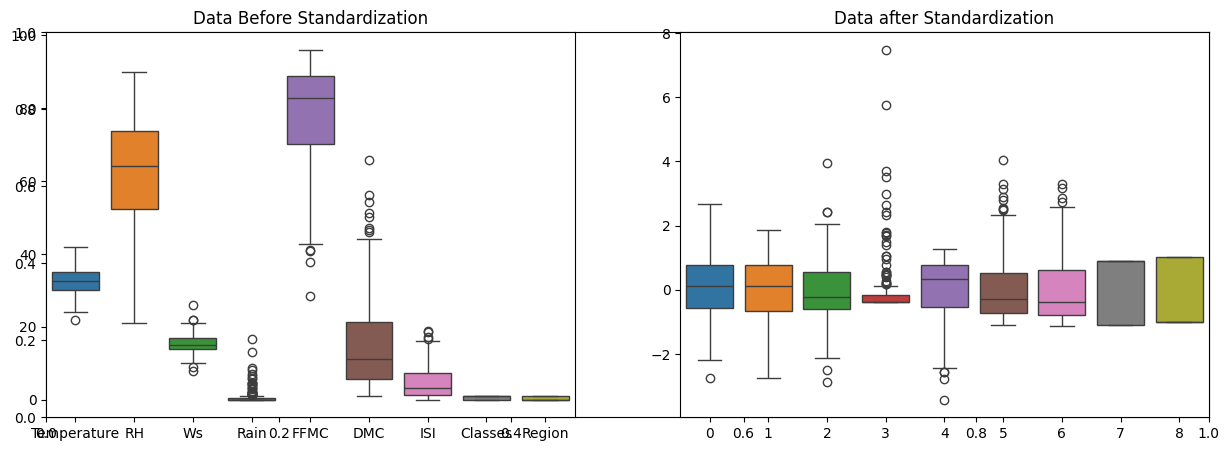

In [35]:
## Effects of standardization
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('Data Before Standardization')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('Data after Standardization')

In [43]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score

MSE  0.6742766873791582
MAE  0.546823646524997
R2 Score  0.9847657384266951


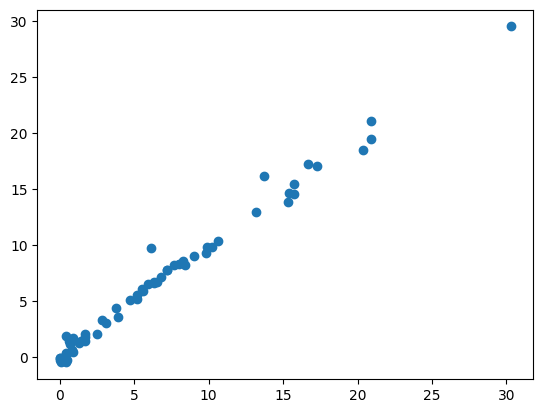

In [44]:
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)
y_pred = regressor.predict(X_test_scaled)
print("MSE ", mse(y_test, y_pred))
print("MAE ", mae(y_test, y_pred))
print("R2 Score ", r2_score(y_test, y_pred))
plt.scatter(y_test, y_pred)

MSE  2.248345891897475
MAE  1.1331759949144087
R2 Score  0.9492020263112388


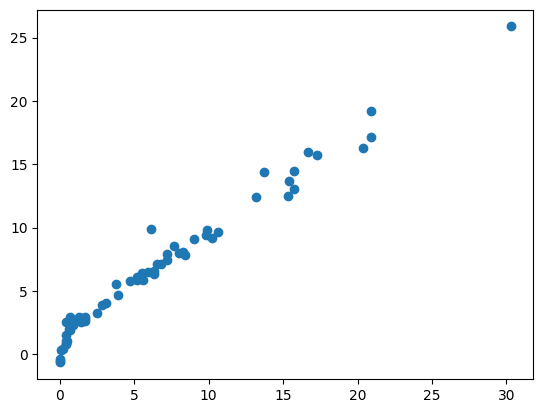

In [ ]:
lasso = Lasso() ## lasso is used for reduce overfitting - L2 Regularization
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
print("MSE ", mse(y_test, y_pred_lasso))
print("MAE ", mae(y_test, y_pred_lasso))
print("R2 Score ", r2_score(y_test, y_pred_lasso))
plt.scatter(y_test, y_pred_lasso)

MSE  0.6949198918152073
MAE  0.5642305340105691
R2 Score  0.9842993364555513


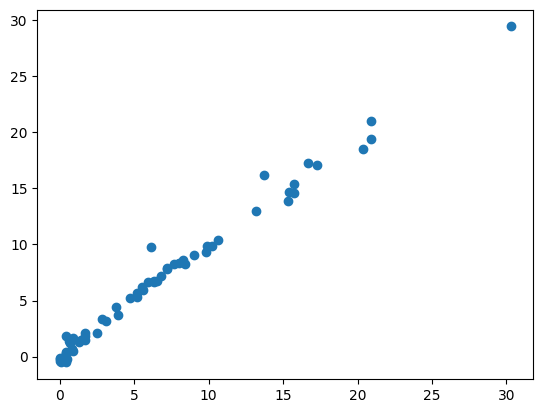

In [ ]:
ridge = Ridge() # It is used for feature selection - L1 Regularization
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print("MSE ", mse(y_test, y_pred_ridge))
print("MAE ", mae(y_test, y_pred_ridge))
print("R2 Score ", r2_score(y_test, y_pred_ridge))
plt.scatter(y_test, y_pred_ridge)

### Cross Validation

In [50]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV

MSE  0.8214458563350043
MAE  0.6358894638564663
R2 Score  0.9814406737205228


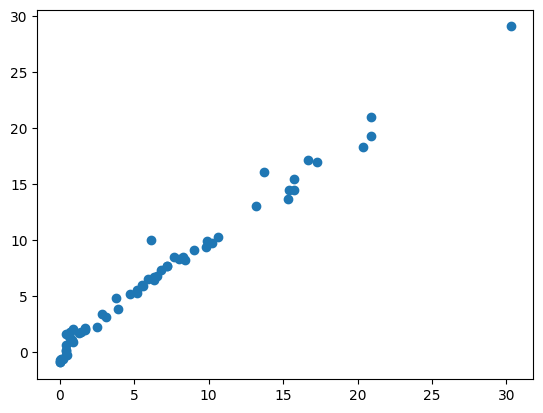

In [48]:
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lassocv = lasso_cv.predict(X_test_scaled)
print("MSE ", mse(y_test, y_pred_lassocv))
print("MAE ", mae(y_test, y_pred_lassocv))
print("R2 Score ", r2_score(y_test, y_pred_lassocv))
plt.scatter(y_test, y_pred_lassocv)

MSE  0.6949198918152073
MAE  0.5642305340105691
R2 Score  0.9842993364555513


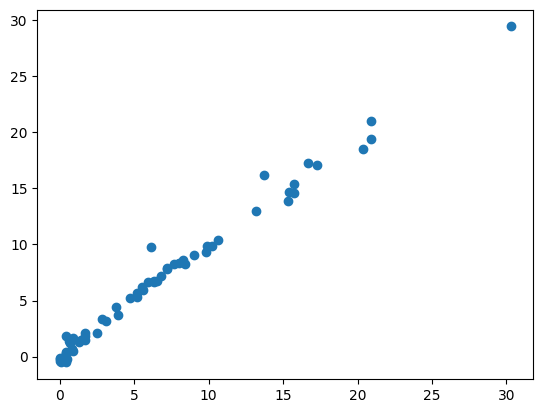

In [49]:
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridgecv = ridge_cv.predict(X_test_scaled)
print("MSE ", mse(y_test, y_pred_ridgecv))
print("MAE ", mae(y_test, y_pred_ridgecv))
print("R2 Score ", r2_score(y_test, y_pred_ridgecv))
plt.scatter(y_test, y_pred_ridgecv)

MSE  0.8222830416276268
MAE  0.6575946731430902
R2 Score  0.9814217587854941


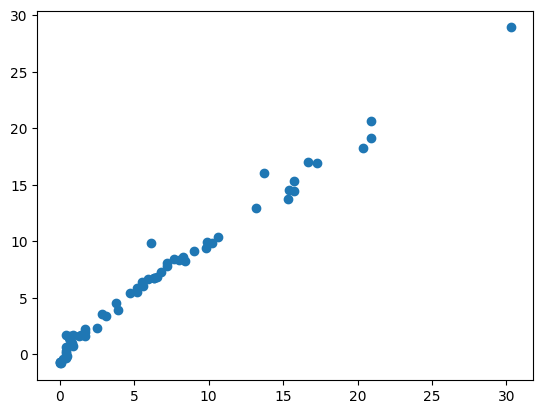

In [51]:
elastic_cv = ElasticNetCV(cv=5)
elastic_cv.fit(X_train_scaled, y_train)
y_pred_elasticcv = elastic_cv.predict(X_test_scaled)
print("MSE ", mse(y_test, y_pred_elasticcv))
print("MAE ", mae(y_test, y_pred_elasticcv))
print("R2 Score ", r2_score(y_test, y_pred_elasticcv))
plt.scatter(y_test, y_pred_elasticcv)

In [52]:
import pickle

In [53]:
pickle.dump(scaler, open('../Models/Standardize.pkl', 'wb'))

In [54]:
pickle.dump(elastic_cv, open('../Models/elasticnet_cv.pkl', 'wb'))